# import and config

In [27]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer

In [28]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()

hf_token = os.getenv("HF_TOKEN")
login(token=hf_token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# Get dataset

In [29]:
splits = {'train': 'vianli_train.jsonl', 'validation': 'vianli_dev.jsonl', 'test': 'vianli_test.jsonl'}
df_train = pd.read_json("hf://datasets/uitnlp/ViANLI/" + splits["train"], lines=True)
df_valid = pd.read_json("hf://datasets/uitnlp/ViANLI/" + splits["validation"], lines=True)
df_test = pd.read_json("hf://datasets/uitnlp/ViANLI/" + splits["test"], lines=True)
df_train[:5]

,uid,premise,hypothesis,label
0,uit_Adver_365_3_11_02,Tọa đàm do Tổng cục Du lịch phối hợp với báo đ...,"Đầu tháng 4 có một buổi gặp mặt trao đổi, nói ...",entailment
1,uit_Adver_1405_5_11_08,Bệnh viện Đa khoa tỉnh Bắc Ninh xin hội chẩn 2...,"Để giúp các chuyên gia đầu ngành, bệnh viện Đa...",entailment
2,uit_Adver_304_2_11_02,"Bộ trưởng Du lịch, tiến sĩ Abdulla Mausoom xác...","3V đại diện cho Visit (Tham quan), Vaccine (Ti...",entailment
3,uit_Adver_1124_1_11_06,Nhờ sự chuyển dịch của người dùng lên trực tuy...,Amazon có doanh thu 3 tháng đầu năm vượt trội ...,entailment
4,uit_Adver_819_3_11_05,Lượng neutron ngày tăng hé lộ FCM đang trải qu...,Hỗn hợp các chất phóng xạ đặc sệt gồm uranium ...,entailment


# Checking imbalance

In [30]:
df_train["label"].unique()

<ArrowStringArray>
['entailment', 'neutral', 'contradiction']
Length: 3, dtype: str

In [31]:
count_label = np.zeros(len(df_train["label"].unique()))
for i, x in enumerate(df_train["label"].unique()) :
    count_label[i] = df_train["label"].value_counts()[x]
count_label, len(count_label)


(array([2615., 2924., 2473.]), 3)

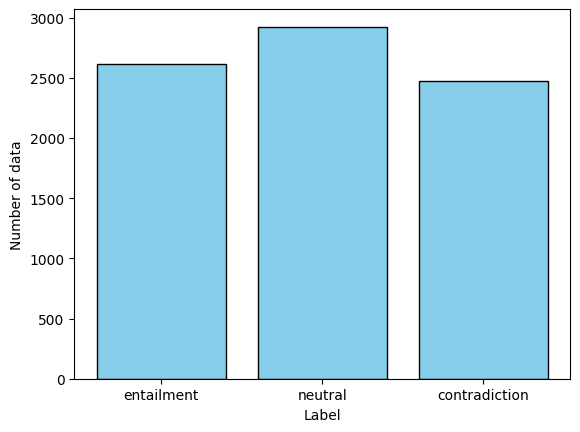

In [32]:
plt.bar(df_train["label"].unique(), count_label, color="skyblue", edgecolor='black')
plt.xlabel("Label")
plt.ylabel("Number of data")
plt.show()

# Tokenize

In [33]:
phobert = AutoModel.from_pretrained("vinai/phobert-base")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [34]:
tokenizer.vocab_size

64000

In [35]:
example = "Tôi yêu Liên Minh Huyền Thoại"
output_example = tokenizer(example)
output_example

{'input_ids': [0, 218, 413, 3490, 1612, 4428, 17078, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

In [36]:
premise_example = "Tôi yêu Liên Minh Huyền Thoại"
hypothesis_example = "Tôi thất nghiệp"

output_example = tokenizer(premise_example, hypothesis_example)

tokenizer.decode(output_example['input_ids'])

'<s> Tôi yêu Liên Minh Huyền Thoại </s> </s> Tôi thất nghiệp </s>'

# Pick max length

In [37]:
def count_token(row):
    ids = tokenizer(row['premise'], row['hypothesis'])['input_ids']
    return len(ids)

In [38]:
df_train['token_length'] = df_train.apply(count_token, axis=1)
df_train[:5]

,uid,premise,hypothesis,label,token_length
0,uit_Adver_365_3_11_02,Tọa đàm do Tổng cục Du lịch phối hợp với báo đ...,"Đầu tháng 4 có một buổi gặp mặt trao đổi, nói ...",entailment,58
1,uit_Adver_1405_5_11_08,Bệnh viện Đa khoa tỉnh Bắc Ninh xin hội chẩn 2...,"Để giúp các chuyên gia đầu ngành, bệnh viện Đa...",entailment,80
2,uit_Adver_304_2_11_02,"Bộ trưởng Du lịch, tiến sĩ Abdulla Mausoom xác...","3V đại diện cho Visit (Tham quan), Vaccine (Ti...",entailment,87
3,uit_Adver_1124_1_11_06,Nhờ sự chuyển dịch của người dùng lên trực tuy...,Amazon có doanh thu 3 tháng đầu năm vượt trội ...,entailment,53
4,uit_Adver_819_3_11_05,Lượng neutron ngày tăng hé lộ FCM đang trải qu...,Hỗn hợp các chất phóng xạ đặc sệt gồm uranium ...,entailment,65


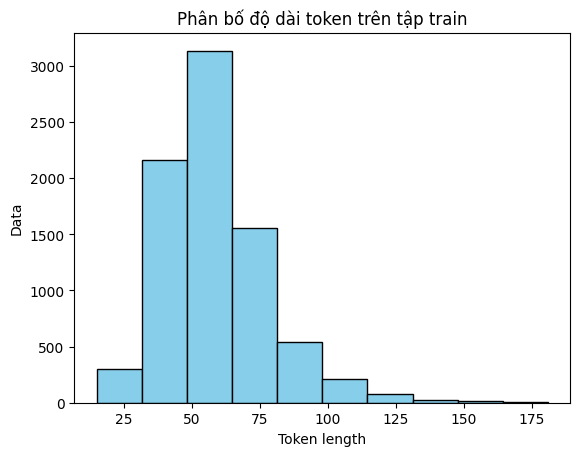

In [39]:
plt.hist(df_train.token_length, color='skyblue', edgecolor='black')
plt.title('Phân bố độ dài token trên tập train')
plt.ylabel('Data')
plt.xlabel('Token length')
plt.show()